# Bulgarian Dialect Region Classification — Whisper-small

**Task:** Classify a fixed-length audio clip into one of 4 Bulgarian dialect regions:
- `NW` — Northwest (Northwestern + Transitional Belogradčik/Trŭn)
- `NE` — Northeast (Northeastern: Moesian, Central Balkan, Sub-Balkan, Eastern Balkan)
- `SW` — Southwest (Southwestern + Western Rupic)
- `SE` — Southeast (Eastern Rupic: Thracian, Strandža + Central Rupic / Rhodope)

**Source:** *Bulgarian Dialectology as Living Tradition* (bulgariandialectology.org)

**Data path:** `/kaggle/input/datasets/antoniogatovski/bulgarian-dialogue-audio/bulgarian_dialect_audio/`

**Architecture** (identical to Slavic LID tier3_c_train.ipynb):
```
Audio clip  (CHUNK_S seconds @ 16 kHz)
  -> Whisper log-Mel feature extractor  (80 mels, 10 ms hop)
  -> whisper-small encoder              [Phase 1: FROZEN  Phase 2: fine-tuned]
  -> mean pool over time                -> (B, 768)
  -> Linear(768, 256) + ReLU + Dropout(0.3)
  -> Linear(256, 4)                     -> logits
```

**Training — 10 epochs:**
- Phase 1 (4 ep): encoder frozen, head only, LR 1e-3
- Phase 2 (6 ep): full fine-tune, encoder LR 1e-5 / head LR 1e-4, cosine decay

**Workflow:**
1. **Map** every MP3 filename → village → region (hardcoded from official corpus)
2. **Segment** each long recording into non-overlapping clips of `CHUNK_S` seconds
3. **Precompute** Whisper log-Mel arrays → NPZ shards on `/kaggle/working/`
4. **Train** and evaluate with confusion matrix + t-SNE
5. Save `results.json` and checkpoint

**Accelerator:** GPU T4 x2 | **Internet:** on (for Whisper weights download)

In [1]:
!pip uninstall -q -y torchvision
!pip install -q -U transformers huggingface_hub soundfile librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.26 requires torchvision, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


## 1. Config

In [2]:
# ── Audio ──────────────────────────────────────────────────────────────────────
AUDIO_DIR  = "/kaggle/input/datasets/antoniogatovski/bulgarian-dialogue-audio/bulgarian_dialect_audio"
CHUNK_S    = 10          # seconds per clip — long enough for dialect features
HOP_S      = 10          # non-overlapping (hop == chunk = no overlap)
MIN_CLIPS  = 5           # discard a recording that yields fewer clips than this
SAMPLE_RATE = 16_000

# ── Model ──────────────────────────────────────────────────────────────────────
WHISPER_ID  = "openai/whisper-small"
N_MELS      = 80
CHUNK_SAMPLES    = CHUNK_S * SAMPLE_RATE           # 160 000
VALID_MEL_FRAMES = CHUNK_SAMPLES // 160            # Whisper hop = 160 samples
VALID_ENC_FRAMES = VALID_MEL_FRAMES // 2           # after Whisper's stride-2 conv

# ── Training ───────────────────────────────────────────────────────────────────
SEED        = 42
TRAIN_RATIO = 0.70       # per recording: 70% train
VAL_RATIO   = 0.15       # 15% val   — used for early stopping / model selection
TEST_RATIO  = 0.15       # 15% test  — held-out, touched ONCE at the very end
BATCH_SIZE  = None       # set automatically below (128 for 2× T4, 64 for 1× T4)
EPOCHS      = 10
HEAD_EPOCHS = 4
HEAD_LR     = 1e-3
ENCODER_LR  = 1e-5
HEAD_LR_FT  = 1e-4
WD          = 1e-4

# ── Paths ──────────────────────────────────────────────────────────────────────
MELS_DIR = "/kaggle/working/mels"
CKPT_DIR = "/kaggle/working/bg_dialect_region"

import os
os.makedirs(MELS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"CHUNK_S={CHUNK_S}s  MEL_FRAMES={VALID_MEL_FRAMES}  ENC_FRAMES={VALID_ENC_FRAMES}")
print(f"Split: train={TRAIN_RATIO:.0%} / val={VAL_RATIO:.0%} / test={TEST_RATIO:.0%}")

CHUNK_S=10s  MEL_FRAMES=1000  ENC_FRAMES=500
Split: train=70% / val=15% / test=15%


## 2. Village → Region Mapping

Every village is assigned to one of 4 regions based on official dialect group labels
from *Bulgarian Dialectology as Living Tradition* (bulgariandialectology.org).
See `bulgarian_dialects_region_map.md` for full provenance.

In [3]:
# Maps canonical village key -> region label
# Keys match what parse_village() returns (lowercase, spaces, no numbers/suffixes)
VILLAGE_REGION = {
    # NW — Northwestern + Transitional Belogradchik / Trun
    "archar":         "NW",
    "bela":           "NW",
    "breste":         "NW",
    "dolna sekirna":  "NW",
    "gigen":          "NW",
    "glavanovci":     "NW",
    "gradec":         "NW",
    "nasalevci":      "NW",
    "petyrnica":      "NW",
    "rajanovci":      "NW",
    "repljana":       "NW",
    "stakevci":       "NW",
    "tyrnjane":       "NW",
    "vladimirovo":    "NW",
    "vyrbovo":        "NW",
    # NE — Northeastern
    "bangejci":       "NE",
    "chernovryh":     "NE",
    "drjanovec":      "NE",
    "garvan":         "NE",
    "golica":         "NE",
    "iskrica":        "NE",
    "izgrev var":     "NE",   # Izgrev/Var (Varna area)
    "koljo marinovo": "NE",
    "kozichino":      "NE",
    "markovo":        "NE",
    "oborishte":      "NE",
    "petrov dol":     "NE",
    "prestoj":        "NE",
    "srebyrna":       "NE",
    "stanchov han":   "NE",
    "trjavna":        "NE",
    "vasiljovo":      "NE",
    # SW — Southwestern + Western Rupic
    "babjak":         "SW",
    "bansko":         "SW",
    "baskalci":       "SW",
    "belica":         "SW",
    "bosnek":         "SW",
    "dolno draglishta": "SW",
    "dolno uino":     "SW",
    "eremija":        "SW",
    "godeshevo":      "SW",
    "gorna krushica": "SW",
    "gorno vyrshilo": "SW",
    "kovachevo":      "SW",
    "krushevo":       "SW",
    "oreshe":         "SW",
    "skryt":          "SW",
    # SE — Eastern Rupic + Central Rupic / Rhodope
    "bryshljan":      "SE",
    "chokmanovo":     "SE",
    "drabishna":      "SE",
    "gela":           "SE",
    "grashevo":       "SE",
    "huhla":          "SE",
    "hvojna":         "SE",
    "izgrev car":     "SE",   # Izgrev/Car (Tsarevo, Burgas)
    "kralevo":        "SE",
    "leshtak":        "SE",
    "malevo asgr":    "SE",   # Malevo (Asenovgrad)
    "malevo hsk":     "SE",   # Malevo (Haskovo)
    "mogilica":       "SE",
    "momchilovci":    "SE",
    "pavelsko":       "SE",
    "rakovski":       "SE",
    "shiroka lyka":   "SE",
    "shumnatica":     "SE",
    "stalevo":        "SE",
    "stikyl":         "SE",
    "stoilovo":       "SE",
    "stojkite":       "SE",
    "sveta petka":    "SE",
    "syrnica":        "SE",
    "tihomir":        "SE",
    "trynchovica":    "SE",
    "vuglarevo":      "SE",   # also covers vyglarovo (same village)
    "vyglarovo":      "SE",
    "vyrbina":        "SE",
    "zabernovo":      "SE",
    "zhitnica":       "SE",
}

REGIONS   = ["NW", "NE", "SW", "SE"]
REGION2ID = {r: i for i, r in enumerate(REGIONS)}
ID2REGION = {i: r for i, r in enumerate(REGIONS)}
NUM_CLASSES = len(REGIONS)
print(f"Regions: {REGIONS}")
print(f"Villages mapped: {len(VILLAGE_REGION)}")

Regions: ['NW', 'NE', 'SW', 'SE']
Villages mapped: 78


## 3. Parse filenames and assign regions

In [4]:
import re, pathlib, urllib.parse, collections

AUDIO_EXTS = {'.mp3', '.wav', '.flac', '.ogg', '.m4a'}

_SUFFIX_RE = re.compile(
    r'[\._\s\-]?(newest|newer|latest|newst|new|final|last|cut|copy|bg)'
    r'[\._\s\d]*',
    re.IGNORECASE
)

def parse_village(fpath):
    """Canonical village key from file path: lowercase, spaces, no numbers/suffixes."""
    stem = urllib.parse.unquote(pathlib.Path(fpath).stem)
    stem = re.sub(r'[%,]', ' ', stem)
    stem = _SUFFIX_RE.sub('', stem)
    stem = re.sub(r'[\._\s\-]+\d+[\d\._\s]*$', '', stem)
    stem = re.sub(r'\d+$', '', stem)
    stem = re.sub(r'[\._\s\-]+$', '', stem)
    stem = stem.strip().lower()
    stem = re.sub(r'[\._\-]+', ' ', stem)
    # Special cases that need normalisation
    stem = re.sub(r'\bkru[sš]ica\b', 'krushica', stem)   # gorna krušica
    stem = re.sub(r'vyglarovo', 'vuglarevo', stem)        # spelling variant
    # MalevoAsgr / MalevoHsk -> malevo asgr / malevo hsk
    stem = re.sub(r'malevoasgr', 'malevo asgr', stem)
    stem = re.sub(r'malevohsk',  'malevo hsk',  stem)
    # IzgrevCar / Izgrev.Vrn -> izgrev car / izgrev var
    stem = re.sub(r'izgrevcar',      'izgrev car', stem)
    stem = re.sub(r'izgrev vrn\d*',  'izgrev var', stem)
    stem = re.sub(r'izgrev\.vrn\d*', 'izgrev var', stem)
    return stem.strip()

# Collect all audio files
all_files = sorted(
    p for p in pathlib.Path(AUDIO_DIR).iterdir()
    if p.suffix.lower() in AUDIO_EXTS
)
print(f"Total audio files found: {len(all_files)}")

# Assign region to each file
file_records = []   # list of (path, village_key, region_label)
skipped = []
for f in all_files:
    vkey = parse_village(f)
    region = VILLAGE_REGION.get(vkey)
    if region is None:
        skipped.append((f.name, vkey))
    else:
        file_records.append((f, vkey, region))

print(f"Mapped:  {len(file_records)} files")
print(f"Skipped: {len(skipped)} files (village key not in VILLAGE_REGION)")
if skipped:
    print("  -- skipped:")
    for fname, vkey in skipped:
        print(f"    {fname}  -> key='{vkey}'")
    print("  Fix: add the key to VILLAGE_REGION or fix parse_village()")

Total audio files found: 205
Mapped:  205 files
Skipped: 0 files (village key not in VILLAGE_REGION)


In [5]:
# Region counts
region_counts = collections.Counter(r for _, _, r in file_records)
print("Recordings per region:")
for r in REGIONS:
    print(f"  {r}: {region_counts[r]:>3} recordings")

Recordings per region:
  NW:  38 recordings
  NE:  41 recordings
  SW:  42 recordings
  SE:  84 recordings


## 4. Segment recordings and precompute Whisper log-Mel arrays

Each long recording is sliced into non-overlapping `CHUNK_S`-second windows.
The last partial window is discarded if it is shorter than `CHUNK_S`.

**Split strategy — per recording (not globally):**
- First 70% of clips → **train**
- Next 15% → **val** (used for early stopping and model selection)
- Last 15% → **test** (held-out; only evaluated once at the very end)

Keeping clips from the same recording in the same split prevents any leakage
from a single speaker appearing in both train and test.

In [6]:
import gc, glob, time, io, json, random
import numpy as np
import soundfile as sf
import librosa
from transformers import WhisperFeatureExtractor
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)

feature_extractor = WhisperFeatureExtractor.from_pretrained(WHISPER_ID)
print(f"Feature extractor ready: {N_MELS} mels, {VALID_MEL_FRAMES} frames per clip")

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

Feature extractor ready: 80 mels, 1000 frames per clip


In [7]:
def load_audio_full(path):
    """Load an entire audio file as float32 mono at SAMPLE_RATE."""
    try:
        wav, sr = sf.read(str(path), dtype='float32', always_2d=False)
    except Exception:
        wav, sr = librosa.load(str(path), sr=None, mono=True)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != SAMPLE_RATE:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)
    return wav.astype(np.float32)


def slice_clips(wav):
    """Slice waveform into non-overlapping clips of CHUNK_SAMPLES. Drop the tail."""
    n_clips = len(wav) // CHUNK_SAMPLES
    return [wav[i * CHUNK_SAMPLES:(i + 1) * CHUNK_SAMPLES] for i in range(n_clips)]


def wavs_to_mels(wavs, batch=64):
    """Convert a list of float32 waveforms to float16 mel arrays (N, N_MELS, VALID_MEL_FRAMES)."""
    out = np.empty((len(wavs), N_MELS, VALID_MEL_FRAMES), dtype=np.float16)
    for start in range(0, len(wavs), batch):
        chunk = wavs[start:start + batch]
        feats = feature_extractor(
            chunk, sampling_rate=SAMPLE_RATE, return_tensors="np"
        ).input_features  # (B, 80, 3000)
        out[start:start + len(chunk)] = feats[:, :, :VALID_MEL_FRAMES].astype(np.float16)
    return out


# Shard helpers
SHARD_SIZE = 2000

def _shard_path(split, idx):
    return os.path.join(MELS_DIR, f"{split}_mel_f16_{idx:05d}.npz")

def _input_shard(split, idx):
    p = _shard_path(split, idx)
    if os.path.exists(p):
        return p
    hits = glob.glob(f"/kaggle/input/**/{split}_mel_f16_{idx:05d}.npz", recursive=True)
    return hits[0] if hits else None

print("Helpers ready.")

Helpers ready.


In [8]:
# ── Check if shards already exist ─────────────────────────────────────────────
# (attach the output of a previous run as a Kaggle dataset to skip extraction)
existing_train = glob.glob("/kaggle/input/**/train_mel_f16_*.npz", recursive=True)
existing_val   = glob.glob("/kaggle/input/**/val_mel_f16_*.npz",   recursive=True)
existing_test  = glob.glob("/kaggle/input/**/test_mel_f16_*.npz",  recursive=True)
SHARDS_READY   = bool(existing_train and existing_val and existing_test)
print(f"Pre-existing shards: train={len(existing_train)} val={len(existing_val)} test={len(existing_test)}")
print("Extraction: SKIP" if SHARDS_READY else "Extraction: WILL RUN")

Pre-existing shards: train=0 val=0 test=0
Extraction: WILL RUN


In [9]:
if not SHARDS_READY:
    print("Extracting mel clips from recordings...")
    print(f"  Chunk={CHUNK_S}s  |  Split: train={TRAIN_RATIO:.0%} / val={VAL_RATIO:.0%} / test={TEST_RATIO:.0%}")

    train_wavs, train_labels = [], []
    val_wavs,   val_labels   = [], []
    test_wavs,  test_labels  = [], []
    skipped_recordings = []

    for fpath, vkey, region in tqdm(file_records, desc="Loading & slicing"):
        try:
            wav = load_audio_full(fpath)
        except Exception as e:
            skipped_recordings.append((fpath.name, str(e)))
            continue

        clips = slice_clips(wav)
        if len(clips) < MIN_CLIPS:
            skipped_recordings.append((fpath.name, f"only {len(clips)} clips"))
            continue

        label   = REGION2ID[region]
        n       = len(clips)
        n_train = max(1, int(n * TRAIN_RATIO))
        n_val   = max(1, int(n * VAL_RATIO))
        # test gets the remainder so rounding errors don't lose clips
        for clip in clips[:n_train]:
            train_wavs.append(clip);  train_labels.append(label)
        for clip in clips[n_train:n_train + n_val]:
            val_wavs.append(clip);    val_labels.append(label)
        for clip in clips[n_train + n_val:]:
            test_wavs.append(clip);   test_labels.append(label)

    if skipped_recordings:
        print(f"\nSkipped {len(skipped_recordings)} recordings:")
        for name, reason in skipped_recordings:
            print(f"  {name}: {reason}")

    print(f"\nClips: train={len(train_wavs):,}  val={len(val_wavs):,}  test={len(test_wavs):,}")
    for r in REGIONS:
        rid = REGION2ID[r]
        tr = sum(1 for l in train_labels if l == rid)
        va = sum(1 for l in val_labels   if l == rid)
        te = sum(1 for l in test_labels  if l == rid)
        print(f"  {r}: train={tr:,}  val={va:,}  test={te:,}")

    def save_shards(wavs, labels, split):
        idx      = np.random.default_rng(SEED).permutation(len(wavs))
        wavs_s   = [wavs[i]   for i in idx]
        labels_s = [labels[i] for i in idx]
        n_shards = (len(wavs_s) + SHARD_SIZE - 1) // SHARD_SIZE
        print(f"  Saving {split}: {len(wavs_s):,} clips in {n_shards} shards...")
        for si in tqdm(range(n_shards), desc=f"  {split} shards"):
            start = si * SHARD_SIZE
            end   = min(len(wavs_s), start + SHARD_SIZE)
            X     = wavs_to_mels(wavs_s[start:end])
            y     = np.array(labels_s[start:end], dtype=np.int32)
            tmp   = _shard_path(split, si)[:-4] + "_tmp"
            np.savez_compressed(tmp, X=X, y=y)
            os.replace(tmp + ".npz", _shard_path(split, si))
        total_gb = sum(os.path.getsize(_shard_path(split, i)) for i in range(n_shards)) / 1e9
        print(f"  {split}: {n_shards} shards, {total_gb:.2f} GB")

    save_shards(train_wavs, train_labels, "train");  del train_wavs;  gc.collect()
    save_shards(val_wavs,   val_labels,   "val");    del val_wavs;    gc.collect()
    save_shards(test_wavs,  test_labels,  "test");   del test_wavs;   gc.collect()

    print("\nExtraction complete!")
    print("TIP: Save Version -> New Dataset -> 'bg-dialects-mels' -> attach next session.")
else:
    print("Shards already present -- skipping extraction.")

Extracting mel clips from recordings...
  Chunk=10s  |  Split: train=70% / val=15% / test=15%


Loading & slicing:   0%|          | 0/205 [00:00<?, ?it/s]


Skipped 8 recordings:
  Bryshljan2.mp3: only 3 clips
  Godeshevo2.mp3: only 2 clips
  Golica1new.mp3: only 4 clips
  Hvojna3.mp3: only 3 clips
  Izgrev.Vrn2_.mp3: only 4 clips
  Shumnatica4.mp3: only 3 clips
  Zhitnica1.mp3: only 4 clips
  dolno_draglishta_2.1.mp3: only 4 clips

Clips: train=3,530  val=690  test=958
  NW: train=655  val=128  test=182
  NE: train=733  val=145  test=198
  SW: train=732  val=144  test=195
  SE: train=1,410  val=273  test=383
  Saving train: 3,530 clips in 2 shards...


  train shards:   0%|          | 0/2 [00:00<?, ?it/s]

  train: 2 shards, 0.50 GB
  Saving val: 690 clips in 1 shards...


  val shards:   0%|          | 0/1 [00:00<?, ?it/s]

  val: 1 shards, 0.10 GB
  Saving test: 958 clips in 1 shards...


  test shards:   0%|          | 0/1 [00:00<?, ?it/s]

  test: 1 shards, 0.14 GB

Extraction complete!
TIP: Save Version -> New Dataset -> 'bg-dialects-mels' -> attach next session.


In [10]:
# ── Load all shards into RAM ───────────────────────────────────────────────────
def load_shards(split):
    paths = sorted(
        glob.glob(f"/kaggle/working/mels/{split}_mel_f16_*.npz") +
        glob.glob(f"/kaggle/input/**/{split}_mel_f16_*.npz", recursive=True)
    )
    seen, unique = set(), []
    for p in paths:
        base = os.path.basename(p)
        if base not in seen:
            seen.add(base); unique.append(p)
    assert unique, f"No shards found for split '{split}'"
    Xs, ys = [], []
    for p in sorted(unique):
        with np.load(p) as d:
            Xs.append(d["X"]); ys.append(d["y"])
    return np.concatenate(Xs), np.concatenate(ys)

print("Loading shards...", flush=True)
X_train, y_train = load_shards("train")
X_val,   y_val   = load_shards("val")
X_test,  y_test  = load_shards("test")
gb = (X_train.nbytes + X_val.nbytes + X_test.nbytes) / 1e9
print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}  (~{gb:.2f} GB RAM)")
print("\nClass balance:")
for i, r in ID2REGION.items():
    print(f"  {r}: train={(y_train==i).sum():,}  val={(y_val==i).sum():,}  test={(y_test==i).sum():,}")

Loading shards...
Train (3530, 80, 1000)  Val (690, 80, 1000)  Test (958, 80, 1000)  (~0.83 GB RAM)

Class balance:
  NW: train=655  val=128  test=182
  NE: train=733  val=145  test=198
  SW: train=732  val=144  test=195
  SE: train=1,410  val=273  test=383


## 5. Dataset & DataLoaders

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
N_GPU   = torch.cuda.device_count() if DEVICE.type == "cuda" else 0
BATCH_SIZE = 128 if N_GPU > 1 else 64
print(f"Device: {DEVICE} | n_gpu: {N_GPU} | AMP: {USE_AMP} | batch: {BATCH_SIZE}")


class DialectDataset(Dataset):
    def __init__(self, X, y):
        self.X = X; self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx].astype(np.float32)), int(self.y[idx])


# Class weights computed from train split only
counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
weights = counts.sum() / (NUM_CLASSES * counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print("Class weights (inverse-frequency):")
for i, r in ID2REGION.items():
    print(f"  {r}: {weights[i]:.3f}")

_kw = dict(num_workers=4, pin_memory=True, persistent_workers=True)
train_loader = DataLoader(DialectDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  **_kw)
val_loader   = DataLoader(DialectDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, **_kw)
test_loader  = DataLoader(DialectDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, **_kw)
print(f"\nTrain {len(train_loader)} batches | Val {len(val_loader)} batches | Test {len(test_loader)} batches")
feat, lbl = DialectDataset(X_train, y_train)[0]
print(f"Sample shape: {tuple(feat.shape)}  label: {ID2REGION[lbl]}")

Device: cuda | n_gpu: 2 | AMP: True | batch: 128
Class weights (inverse-frequency):
  NW: 1.347
  NE: 1.204
  SW: 1.206
  SE: 0.626

Train 28 batches | Val 6 batches | Test 8 batches
Sample shape: (80, 1000)  label: SE


## 6. Model: Whisper-small encoder + classification head

Identical architecture to `tier3_c_train.ipynb`, adapted for:
- 4 output classes instead of 8
- Variable `CHUNK_S` (positional table patched to `VALID_ENC_FRAMES`)

In [12]:
from transformers import WhisperModel

class WhisperRegionLID(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, whisper_id=WHISPER_ID,
                 enc_frames=VALID_ENC_FRAMES):
        super().__init__()
        whisper = WhisperModel.from_pretrained(whisper_id)
        self.encoder = whisper.get_encoder()
        d_model = whisper.config.d_model  # 768 for whisper-small

        # Patch positional table from 1500 -> enc_frames
        self.encoder.config.max_source_positions = enc_frames
        if hasattr(self.encoder, "max_source_positions"):
            self.encoder.max_source_positions = enc_frames
        emb = self.encoder.embed_positions
        emb.weight = nn.Parameter(emb.weight.data[:enc_frames].clone())
        emb.num_embeddings = enc_frames

        self.embed      = nn.Sequential(
            nn.Linear(d_model, 256), nn.ReLU(inplace=True), nn.Dropout(0.3)
        )
        self.classifier = nn.Linear(256, n_classes)
        self._use_amp   = USE_AMP

    def _pool(self, x):
        return self.encoder(x).last_hidden_state.mean(dim=1)

    def forward(self, x):
        with autocast("cuda", enabled=self._use_amp, dtype=torch.float16):
            return self.classifier(self.embed(self._pool(x)))

    def get_embeddings(self, x):
        with autocast("cuda", enabled=self._use_amp, dtype=torch.float16):
            return self.embed(self._pool(x))

    def freeze_encoder(self):
        for p in self.encoder.parameters(): p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.encoder.parameters(): p.requires_grad = True

In [13]:
model = WhisperRegionLID().to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"DataParallel across {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

core = model.module if isinstance(model, nn.DataParallel) else model

n_all   = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: total={n_all:,}  trainable={n_train:,}")

dummy = torch.zeros(2, N_MELS, VALID_MEL_FRAMES, device=DEVICE)
with torch.no_grad():
    print(f"Forward shape:   {tuple(model(dummy).shape)}")
    print(f"Embedding shape: {tuple(core.get_embeddings(dummy).shape)}")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

DataParallel across 2 GPUs
Params: total=87,584,004  trainable=87,584,004
Forward shape:   (2, 4)
Embedding shape: (2, 256)


## 7. Training

- **Phase 1 (4 ep):** encoder frozen, head only, LR 1e-3
- **Phase 2 (6 ep):** full fine-tune, encoder LR 1e-5, head LR 1e-4, cosine LR
- **Loss:** weighted CrossEntropy (compensates for SE imbalance)

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
try:
    scaler = GradScaler("cuda", enabled=USE_AMP)
except TypeError:
    scaler = GradScaler(enabled=USE_AMP)


def run_epoch(model, loader, criterion, optimizer, scaler, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for feats, labels in tqdm(loader, leave=False):
            feats  = feats.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(feats).float()   # cast fp16 -> fp32 for loss
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            bs = labels.size(0)
            total_loss += loss.item() * bs
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += bs
    return total_loss / total, correct / total


print("Training plan:")
print(f"  Phase 1: {HEAD_EPOCHS} epochs  (head only, LR={HEAD_LR})")
print(f"  Phase 2: {EPOCHS - HEAD_EPOCHS} epochs  (full fine-tune, encoder LR={ENCODER_LR}, head LR={HEAD_LR_FT})")

Training plan:
  Phase 1: 4 epochs  (head only, LR=0.001)
  Phase 2: 6 epochs  (full fine-tune, encoder LR=1e-05, head LR=0.0001)


In [15]:
import time, matplotlib.pyplot as plt, matplotlib.ticker as mticker

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_state   = None

# ── Phase 1: head only ─────────────────────────────────────────────────────────
core.freeze_encoder()
optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=HEAD_LR, weight_decay=WD
)
print(f"Phase 1 — head only ({HEAD_EPOCHS} epochs)", flush=True)
for epoch in range(1, HEAD_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scaler, True)
    va_loss, va_acc = run_epoch(model, val_loader,   criterion, optimizer, scaler, False)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    print(f"[head] ep {epoch:2d}/{EPOCHS}  "
          f"train {tr_loss:.4f}/{tr_acc:.3f}  "
          f"val {va_loss:.4f}/{va_acc:.3f}  {time.time()-t0:.0f}s", flush=True)

# ── Phase 2: fine-tune all ─────────────────────────────────────────────────────
core.unfreeze_encoder()
optimizer = torch.optim.AdamW([
    {"params": core.encoder.parameters(),                                           "lr": ENCODER_LR},
    {"params": list(core.embed.parameters()) + list(core.classifier.parameters()), "lr": HEAD_LR_FT},
], weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - HEAD_EPOCHS
)

print(f"\nPhase 2 — full fine-tune ({EPOCHS - HEAD_EPOCHS} epochs)", flush=True)
for epoch in range(HEAD_EPOCHS + 1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scaler, True)
    va_loss, va_acc = run_epoch(model, val_loader,   criterion, optimizer, scaler, False)
    scheduler.step()
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    tag = " *" if va_acc > best_val_acc else ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state   = {k: v.cpu().clone() for k, v in core.state_dict().items()}
    print(f"[ft]   ep {epoch:2d}/{EPOCHS}  "
          f"train {tr_loss:.4f}/{tr_acc:.3f}  "
          f"val {va_loss:.4f}/{va_acc:.3f}  {time.time()-t0:.0f}s{tag}", flush=True)

print(f"\nBest val acc: {best_val_acc:.4f}")

Phase 1 — head only (4 epochs)


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

[head] ep  1/10  train 1.2648/0.405  val 1.1769/0.484  19s


  0%|          | 0/28 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

[ft]   ep  9/10  train 0.0806/0.986  val 0.3278/0.877  49s *


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

[ft]   ep 10/10  train 0.0640/0.993  val 0.3237/0.884  49s *

Best val acc: 0.8841


In [16]:
_hparams = {
    "backbone": WHISPER_ID,
    "feature": f"whisper-logmel-{N_MELS}x{VALID_MEL_FRAMES} ({CHUNK_S}s window)",
    "n_classes": NUM_CLASSES, "regions": REGIONS,
    "epochs": EPOCHS, "head_epochs": HEAD_EPOCHS,
    "head_lr": HEAD_LR, "encoder_lr": ENCODER_LR, "head_lr_ft": HEAD_LR_FT,
    "batch": BATCH_SIZE, "amp": USE_AMP, "n_gpu": N_GPU,
    "train_ratio": TRAIN_RATIO, "chunk_s": CHUNK_S, "seed": SEED,
}
torch.save({"model_state": core.state_dict(), "history": history, "hparams": _hparams},
           f"{CKPT_DIR}/whisper_region_final.pt")
if best_state:
    torch.save({"model_state": best_state, "history": history, "hparams": _hparams},
               f"{CKPT_DIR}/whisper_region_best.pt")
    print(f"Best ckpt (val acc {best_val_acc:.4f}) -> {CKPT_DIR}/whisper_region_best.pt")
print(f"Final ckpt -> {CKPT_DIR}/whisper_region_final.pt")

Best ckpt (val acc 0.8841) -> /kaggle/working/bg_dialect_region/whisper_region_best.pt
Final ckpt -> /kaggle/working/bg_dialect_region/whisper_region_final.pt


## 8. Learning curves

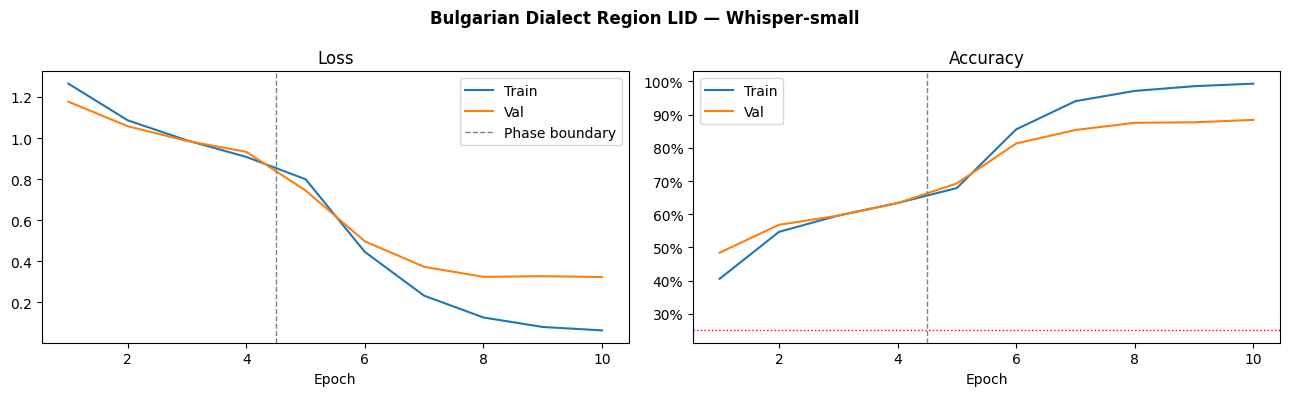

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, history["train_loss"], label="Train")
ax1.plot(ep, history["val_loss"],   label="Val")
ax1.axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--", lw=1, label="Phase boundary")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(ep, history["train_acc"], label="Train")
ax2.plot(ep, history["val_acc"],   label="Val")
ax2.axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--", lw=1)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.axhline(1 / NUM_CLASSES, color="red", ls=":", lw=1, label="Random")

plt.suptitle("Bulgarian Dialect Region LID — Whisper-small", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150); plt.show()

## 9. Evaluation — Val and Test

Val numbers are what the model was selected on (early stopping).  
Test numbers are the **reportable** figures for the paper — the model never saw this data during training.

In [18]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE

# Load best checkpoint
if best_state:
    core.load_state_dict(best_state)
    print(f"Loaded best checkpoint (val acc {best_val_acc:.4f})")

@torch.no_grad()
def evaluate(loader, collect_emb=False, desc="Eval"):
    model.eval()
    preds, labels, embs = [], [], []
    for feats, y in tqdm(loader, desc=desc):
        feats = feats.to(DEVICE, non_blocking=True)
        emb    = core.get_embeddings(feats).float()
        logits = core.classifier(emb)
        preds.extend(logits.argmax(1).cpu().tolist())
        labels.extend(y.tolist())
        if collect_emb:
            embs.append(emb.cpu().numpy())
    p, l = np.array(preds), np.array(labels)
    return p, l, (np.concatenate(embs) if collect_emb else None)


# ── Val ────────────────────────────────────────────────────────────────────────
val_preds, val_labels, _ = evaluate(val_loader, desc="Val")
val_acc = (val_preds == val_labels).mean()
val_f1  = f1_score(val_labels, val_preds, average="macro")
print(f"[VAL]   acc={val_acc:.4f} ({val_acc*100:.2f}%)  macro-F1={val_f1:.4f}")

# ── Test (held-out) ────────────────────────────────────────────────────────────
test_preds, test_labels, test_emb = evaluate(test_loader, collect_emb=True, desc="Test")
test_acc = (test_preds == test_labels).mean()
test_f1  = f1_score(test_labels, test_preds, average="macro")
print(f"[TEST]  acc={test_acc:.4f} ({test_acc*100:.2f}%)  macro-F1={test_f1:.4f}")
print(f"Random baseline: {100/NUM_CLASSES:.1f}%")
print()
print("── Test classification report ──")
print(classification_report(test_labels, test_preds, target_names=REGIONS, digits=3))

Loaded best checkpoint (val acc 0.8841)


Val:   0%|          | 0/6 [00:00<?, ?it/s]

[VAL]   acc=0.8841 (88.41%)  macro-F1=0.8852


Test:   0%|          | 0/8 [00:00<?, ?it/s]

[TEST]  acc=0.8695 (86.95%)  macro-F1=0.8674
Random baseline: 25.0%

── Test classification report ──
              precision    recall  f1-score   support

          NW      0.928     0.852     0.888       182
          NE      0.894     0.854     0.873       198
          SW      0.819     0.836     0.827       195
          SE      0.859     0.903     0.880       383

    accuracy                          0.870       958
   macro avg      0.875     0.861     0.867       958
weighted avg      0.871     0.870     0.870       958



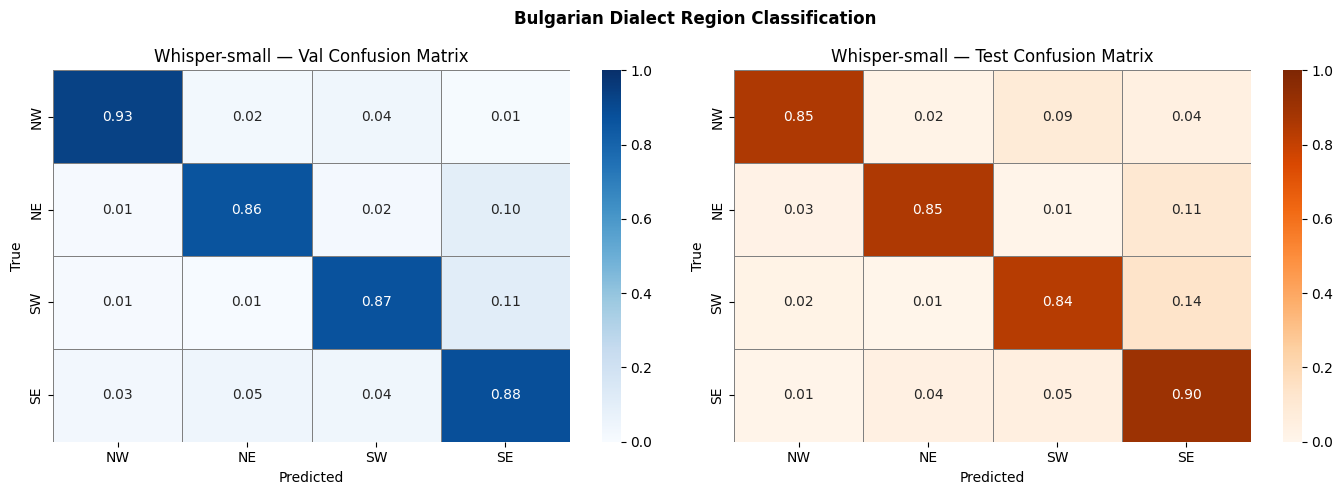

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, labels, title, cmap in [
    (axes[0], val_preds,  val_labels,  "Val",  "Blues"),
    (axes[1], test_preds, test_labels, "Test", "Oranges"),
]:
    cm = confusion_matrix(labels, preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap=cmap,
                xticklabels=REGIONS, yticklabels=REGIONS, ax=ax,
                linewidths=0.5, linecolor="gray", vmin=0, vmax=1)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Whisper-small — {title} Confusion Matrix")

plt.suptitle("Bulgarian Dialect Region Classification", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix.png", dpi=150); plt.show()

## 10. t-SNE of learned embeddings

Stratified t-SNE on TEST embeddings: 182 samples/region -> 728 total
Fitting t-SNE (perplexity=40)...


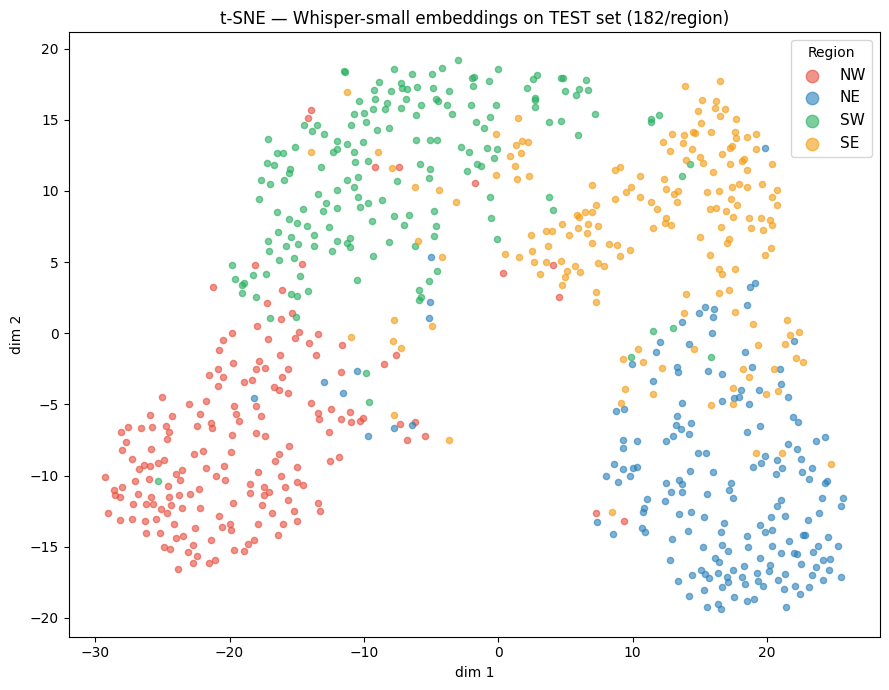

In [20]:
counts_per_class = np.bincount(test_labels, minlength=NUM_CLASSES)
per_class = min(int(counts_per_class.min()), 500)
print(f"Stratified t-SNE on TEST embeddings: {per_class} samples/region -> {per_class * NUM_CLASSES} total")

tsne_rng = np.random.default_rng(SEED)
sel = np.concatenate([
    tsne_rng.choice(np.where(test_labels == c)[0], size=per_class, replace=False)
    for c in range(NUM_CLASSES)
])
tsne_rng.shuffle(sel)

perplexity = min(40, max(5, (len(sel) - 1) // 3))
print(f"Fitting t-SNE (perplexity={perplexity})...", flush=True)
Z = TSNE(n_components=2, perplexity=perplexity,
         random_state=SEED, init="pca").fit_transform(test_emb[sel])

REGION_COLORS = {"NW": "#e74c3c", "NE": "#2980b9", "SW": "#27ae60", "SE": "#f39c12"}
fig, ax = plt.subplots(figsize=(9, 7))
for i, r in enumerate(REGIONS):
    m = test_labels[sel] == i
    ax.scatter(Z[m, 0], Z[m, 1], label=r, color=REGION_COLORS[r], alpha=0.6, s=20)
ax.legend(title="Region", fontsize=11, markerscale=2)
ax.set_title(f"t-SNE — Whisper-small embeddings on TEST set ({per_class}/region)")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150); plt.show()

## 11. Save results.json

In [21]:
def metrics_block(labels, preds):
    rep = classification_report(labels, preds, target_names=REGIONS, digits=4, output_dict=True)
    return {
        "overall_accuracy": float((preds == labels).mean()),
        "macro_f1":         float(f1_score(labels, preds, average="macro")),
        "per_region":       {r: rep[r] for r in REGIONS},
        "macro_avg":        rep["macro avg"],
        "weighted_avg":     rep["weighted avg"],
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
    }

results = {
    "task":     "Bulgarian dialect region classification (NW / NE / SW / SE)",
    "model":    "whisper-small encoder + 2-layer classification head",
    "backbone": WHISPER_ID,
    "feature":  f"whisper log-mel {N_MELS}x{VALID_MEL_FRAMES} ({CHUNK_S}s window)",
    "source":   "bulgariandialectology.org",
    "regions":  REGIONS,
    "village_region_map": VILLAGE_REGION,
    "hparams":  _hparams,
    "history":  history,
    "val":  metrics_block(val_labels,  val_preds),
    "test": metrics_block(test_labels, test_preds),
}
with open(f"{CKPT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved {CKPT_DIR}/results.json")
print()
print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)
print(f"  Val  accuracy: {val_acc:.4f}  macro-F1: {val_f1:.4f}   (model selection)")
print(f"  Test accuracy: {test_acc:.4f}  macro-F1: {test_f1:.4f}   (reportable)")
print(f"  Random baseline: {100/NUM_CLASSES:.1f}%")
print()
print("Per-region Test F1:")
rep_test = classification_report(test_labels, test_preds, target_names=REGIONS, digits=4, output_dict=True)
for r in REGIONS:
    print(f"  {r}: F1={rep_test[r]['f1-score']:.3f}  prec={rep_test[r]['precision']:.3f}  rec={rep_test[r]['recall']:.3f}")

Saved /kaggle/working/bg_dialect_region/results.json

FINAL RESULTS
  Val  accuracy: 0.8841  macro-F1: 0.8852   (model selection)
  Test accuracy: 0.8695  macro-F1: 0.8674   (reportable)
  Random baseline: 25.0%

Per-region Test F1:
  NW: F1=0.888  prec=0.928  rec=0.852
  NE: F1=0.873  prec=0.894  rec=0.854
  SW: F1=0.827  prec=0.819  rec=0.836
  SE: F1=0.880  prec=0.859  rec=0.903
